In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
from xgboost import XGBClassifier
from pulseiq.ml_logic.registry import save_model, load_model
from pulseiq.ml_logic.train import train_model


In [2]:
#!wget 'https://data.mendeley.com/datasets/m8cgwxs9s6/2/files/4c109a9f-2462-4dce-b93c-5789168c5401'

In [3]:
#!unzip raw_data/example.zip

In [4]:
path = "/home/johnny/code/johnnylazoq/pulseIQ/raw_data/DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv"
df = pd.read_csv(path)
df.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


In [5]:
df1 = df.copy()

In [6]:
'''
Droping the ID columns
'''

df1 = df.drop(columns=['systolic_bp', 'diastolic_bp', 'family_diabetes', 'family_hypertension', 'glucose', 'stroke'])

In [7]:
df1.head(2)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,Female,66,1.65,70.2,25.75,0,0,No
1,35,Female,60,1.47,42.5,19.58,0,0,No


In [8]:
'''
Binaryzing Diabetes to 0 = Normal and 1 = Diabetes
'''

map_diabetes = {
    'No': 0,
    'Yes': 1
}

df1['diabetic'] = df1['diabetic'].map(map_diabetes)

In [9]:
'''
Binaryzing Sex to 0 = Female and 1 = Male
'''

map_sex = {
    'Female': 0,
    'Male': 1
}

df1['gender'] = df1['gender'].map(map_sex)

In [10]:
df1.head(4)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,0,66,1.65,70.2,25.75,0,0,0
1,35,0,60,1.47,42.5,19.58,0,0,0
2,62,0,57,1.52,47.0,20.24,0,0,0
3,73,1,55,1.63,57.4,21.72,0,0,0


In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   int64  
 2   pulse_rate              5288 non-null   int64  
 3   height                  5288 non-null   float64
 4   weight                  5288 non-null   float64
 5   bmi                     5288 non-null   float64
 6   hypertensive            5288 non-null   int64  
 7   cardiovascular_disease  5288 non-null   int64  
 8   diabetic                5288 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 371.9 KB


In [12]:
df1.head(2)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,0,66,1.65,70.2,25.75,0,0,0
1,35,0,60,1.47,42.5,19.58,0,0,0


In [13]:

'''
Scanling the dataset
'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()




X_scaled = scaler.set_output(transform='pandas').fit_transform(df1[['age', 'pulse_rate', 'height', 'weight', 'bmi']])
y_diabetic = df1['diabetic']
y_hypertensive = df1['hypertensive']
y_cv = df1['cardiovascular_disease']


In [14]:
y_diabetic

0       0
1       0
2       0
3       0
4       0
       ..
5283    0
5284    1
5285    0
5286    0
5287    0
Name: diabetic, Length: 5288, dtype: int64

<Axes: >

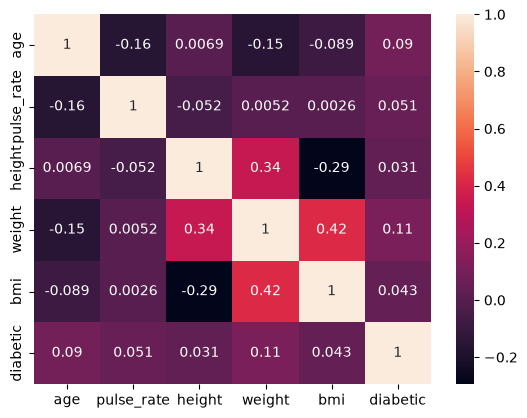

In [15]:
sns.heatmap(pd.concat([X_scaled, y_diabetic], axis=1).corr(), annot=True)

## Logistic Regression baseline

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier

model = LogisticRegression(random_state=42)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_scaled, y_diabetic, train_size=0.7, random_state=42, stratify=y_diabetic)

model.fit(X_train_d, y_train_d)

cv = cross_validate(model, X_train_d, y_train_d, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.683312668902541)

In [17]:
model = LogisticRegression(random_state=42)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_scaled, y_hypertensive, train_size=0.7, random_state=42, stratify=y_hypertensive)

model.fit(X_train_h, y_train_h)

cv = cross_validate(model, X_train_h, y_train_h, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.7366587857844008)

In [18]:
model = LogisticRegression(random_state=42)

X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X_scaled, y_cv, train_size=0.7, random_state=42, stratify=y_cv)

model.fit(X_train_cv, y_train_cv)

cv = cross_validate(model, X_train_cv, y_train_cv, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.7298592578472488)

In [87]:
df1.loc[df1.diabetic ==1]


,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
8,50,1,80,1.68,67.8,24.13,0,0,1
15,35,0,89,1.52,46.6,20.06,0,0,1
16,54,1,99,1.60,62.0,24.22,1,0,1
17,65,0,89,1.52,51.9,22.35,0,0,1
24,60,0,64,1.45,39.9,19.04,1,0,1
...,...,...,...,...,...,...,...,...,...
5179,30,1,88,1.60,40.0,15.63,0,0,1
5253,55,1,67,1.73,76.4,25.61,0,0,1
5254,45,1,67,1.65,73.7,27.04,1,0,1
5263,50,1,85,1.63,59.9,22.67,0,0,1


In [19]:
from sklearn.metrics import roc_auc_score
def model_f(y):
    params={
        'n_estimators': 400,
        'max_depth': 6,
        'learning_rate': 0.9964688888846461,
        'min_child_weight': 1, 'subsample': 0.5004689439033313,
        'colsample_bytree': 0.7613304427154312,
        'gamma': 0.054181861010946, 'reg_alpha': 0.05914008164898518,
        'reg_lambda': 1.1933199710131277e-06
    }
    model_xgb = XGBClassifier(**params)

    model_xgb.fit(X_scaled, y)

    cv_xgb = cross_validate(model_xgb, X_scaled, y, cv=5, scoring=['roc_auc'])

    skf = StratifiedKFold(n_splits=5)
    skf.get_n_splits()

    scores = []

    for i, (train_index, test_index) in enumerate(skf.split(X_scaled, y)):
        X_train = X_scaled.iloc[train_index]
        y_train = y.iloc[train_index]
        X_test = X_scaled.iloc[test_index]
        y_test = y.iloc[test_index]

        model_xgb = XGBClassifier(eval_metric='logloss')

        model_xgb.fit(X_train, y_train)

        y_pred = model_xgb.predict_proba(X_test)[:, 1]


        scores.append(roc_auc_score(y_test, y_pred))
    return np.mean(scores)

In [20]:
scores_d = model_f(y_diabetic)
scores_h = model_f(y_hypertensive)
scores_cv = model_f(y_cv)

In [21]:
scores_d, scores_h, scores_cv

(np.float64(0.6603345635857357),
 np.float64(0.7026213661682676),
 np.float64(0.6345794032709098))

In [22]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = X_scaled
y = y_diabetic

def objective(trial):
    # clasificador
    classifier_name = trial.suggest_categorical('classifier', ['XGBClassifier']) #, 'LogisticRegression', 'RandomForestClassifier'

    if classifier_name == 'XGBClassifier':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1
        }


    # Kfolds
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    X_arr = np.array(X_scaled)
    y_arr = np.array(y_diabetic)

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_train, X_test = X_arr[train_idx], X_arr[val_idx]
        y_train, y_test = y_arr[train_idx], y_arr[val_idx]

        #if classifier_name == 'XGBClassifier':
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        #elif classifier_name == 'LogisticRegression':
        #    model = LogisticRegression(**params)
        #    model.fit(X_train, y_train)
        #else:
        #    model = RandomForestClassifier(**params)
        #    model.fit(X_train, y_train)

        preds = model.predict_proba(X_test)
        score = roc_auc_score(y_test, preds[:,1])
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Mejor ROC_AUC:", study.best_value)
print("Mejores parámetros:", study.best_params)


/home/johnny/.pyenv/versions/pulse_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-27 14:57:30,057] A new study created in memory with name: no-name-6177f5b8-cd02-49bf-8586-b29de6c56503
[I 2026-08-27 14:57:36,768] Trial 0 finished with value: 0.6287868996377812 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 700, 'max_depth': 4, 'learning_rate': 0.39584575562623353, 'min_child_weight': 2, 'subsample': 0.8577392672555157, 'colsample_bytree': 0.9651168250757411, 'gamma': 0.009436488600889198, 'reg_alpha': 5.1405755540422335e-08, 'reg_lambda': 1.2490014910313764e-07}. Best is trial 0 with value: 0.6287868996377812.
[I 2026-08-27 14:57:45,354] Trial 1 finished with value: 0.7198729562870148 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 700, 'max_depth': 3, 'l

Mejor ROC_AUC: 0.7198729562870148
Mejores parámetros: {'classifier': 'XGBClassifier', 'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.0235954482463673, 'min_child_weight': 3, 'subsample': 0.514703291796663, 'colsample_bytree': 0.893723298225632, 'gamma': 0.0001963614188832745, 'reg_alpha': 7.6237446217842875, 'reg_lambda': 5.068518625115473}


In [ ]:
params = {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.015564492219614985, 'min_child_weight': 2, 'subsample': 0.9138162118797337, 'colsample_bytree': 0.8710949067499039, 'gamma': 0.0002543771303215554, 'reg_alpha': 0.5293237315244861, 'reg_lambda': 1.8913627848034716e-08}
model_t = train_model(XGBClassifier, X_scaled, y_diabetic, params)
save_model(model_t, 'diabetic')


Fold 0: AUC = 0.6661
Fold 1: AUC = 0.7290
Fold 2: AUC = 0.7417
Fold 3: AUC = 0.7300
Fold 4: AUC = 0.7277
Mean AUC: 0.7189


(PosixPath('/home/johnny/code/johnnylazoq/pulseIQ/models/XGBoost_diabetic.json'),
 PosixPath('/home/johnny/code/johnnylazoq/pulseIQ/models/config_diabetic.json'))

In [24]:
model_d = load_model('diabetic')

prediction = model_d.predict(X_test_d)

prediction.mean()

np.float64(0.000630119722747322)

## Hypertensive



In [25]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = X_scaled
y = y_hypertensive

def objective(trial):
    # clasificador
    classifier_name = trial.suggest_categorical('classifier', ['XGBClassifier']) #, 'LogisticRegression', 'RandomForestClassifier'

    if classifier_name == 'XGBClassifier':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1
        }


    # Kfolds
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    X_arr = np.array(X_scaled)
    y_arr = np.array(y_hypertensive)

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_train, X_test = X_arr[train_idx], X_arr[val_idx]
        y_train, y_test = y_arr[train_idx], y_arr[val_idx]

        #if classifier_name == 'XGBClassifier':
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        #elif classifier_name == 'LogisticRegression':
        #    model = LogisticRegression(**params)
        #    model.fit(X_train, y_train)
        #else:
        #    model = RandomForestClassifier(**params)
        #    model.fit(X_train, y_train)

        preds = model.predict_proba(X_test)
        score = roc_auc_score(y_test, preds[:,1])
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Mejor ROC_AUC:", study.best_value)
print("Mejores parámetros:", study.best_params)


[I 2026-08-27 14:59:21,397] A new study created in memory with name: no-name-38ef5b5b-8f02-4425-856d-7bca4c1903ac


[I 2026-08-27 14:59:42,866] Trial 0 finished with value: 0.6617902504397812 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 1000, 'max_depth': 8, 'learning_rate': 0.8705168786579062, 'min_child_weight': 2, 'subsample': 0.6297594244377561, 'colsample_bytree': 0.6281015255829117, 'gamma': 0.22503496367464812, 'reg_alpha': 0.1427334584617406, 'reg_lambda': 6.939633671859652e-08}. Best is trial 0 with value: 0.6617902504397812.
[I 2026-08-27 14:59:54,675] Trial 1 finished with value: 0.678915148000445 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.3763071028975231, 'min_child_weight': 5, 'subsample': 0.8177870024086297, 'colsample_bytree': 0.6931830774681351, 'gamma': 5.6265486459913324e-05, 'reg_alpha': 0.0038193828581489678, 'reg_lambda': 0.00031064148347085456}. Best is trial 1 with value: 0.678915148000445.
[I 2026-08-27 15:00:12,159] Trial 2 finished with value: 0.7051921567173525 and parameters: {'classifier': '

Mejor ROC_AUC: 0.7567127217909058
Mejores parámetros: {'classifier': 'XGBClassifier', 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.02562545142728078, 'min_child_weight': 3, 'subsample': 0.7291648296615478, 'colsample_bytree': 0.9875512417376037, 'gamma': 0.0015392155955998548, 'reg_alpha': 0.009823044640349205, 'reg_lambda': 8.215750940536989e-06}


In [26]:
params = {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.09542683553504469, 'min_child_weight': 4, 'subsample': 0.8109771954517436, 'colsample_bytree': 0.6385520942535005, 'gamma': 0.006644822936217805, 'reg_alpha': 2.7462787527728247, 'reg_lambda': 0.00031230682286668537}
model_t = train_model(XGBClassifier, X_scaled, y_hypertensive, params)
save_model(model_t, 'hypertensive')


Fold 0: AUC = 0.7098
Fold 1: AUC = 0.7431
Fold 2: AUC = 0.7016
Fold 3: AUC = 0.7546
Fold 4: AUC = 0.7458
Mean AUC: 0.7310


(PosixPath('/home/johnny/code/johnnylazoq/pulseIQ/models/XGBoost_hypertensive.json'),
 PosixPath('/home/johnny/code/johnnylazoq/pulseIQ/models/config_hypertensive.json'))

In [27]:
model_h = load_model('hypertensive')

prediction = model_h.predict(X_test_h)

prediction.mean()

np.float64(0.023944549464398234)

## Cardiovascular Disease

In [28]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = X_scaled
y = y_cv

def objective(trial):
    # clasificador
    classifier_name = trial.suggest_categorical('classifier', ['XGBClassifier']) #, 'LogisticRegression', 'RandomForestClassifier'

    if classifier_name == 'XGBClassifier':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1
        }


    # Kfolds
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    X_arr = np.array(X_scaled)
    y_arr = np.array(y_cv)

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_train, X_test = X_arr[train_idx], X_arr[val_idx]
        y_train, y_test = y_arr[train_idx], y_arr[val_idx]

        #if classifier_name == 'XGBClassifier':
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        #elif classifier_name == 'LogisticRegression':
        #    model = LogisticRegression(**params)
        #    model.fit(X_train, y_train)
        #else:
        #    model = RandomForestClassifier(**params)
        #    model.fit(X_train, y_train)

        preds = model.predict_proba(X_test)
        score = roc_auc_score(y_test, preds[:,1])
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Mejor ROC_AUC:", study.best_value)
print("Mejores parámetros:", study.best_params)


[I 2026-08-27 15:02:59,017] A new study created in memory with name: no-name-584c7155-1f03-4f34-a920-1e34d30d0e65
[I 2026-08-27 15:03:07,347] Trial 0 finished with value: 0.6285922524022555 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.03812177632366909, 'min_child_weight': 2, 'subsample': 0.7820007845294019, 'colsample_bytree': 0.6153341698556529, 'gamma': 1.204957051570867e-05, 'reg_alpha': 0.5146968462141013, 'reg_lambda': 0.016352915533471155}. Best is trial 0 with value: 0.6285922524022555.
[I 2026-08-27 15:03:28,944] Trial 1 finished with value: 0.6271595140292937 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.044825276274679415, 'min_child_weight': 2, 'subsample': 0.6775768200474581, 'colsample_bytree': 0.5205599578548805, 'gamma': 0.5012533975630067, 'reg_alpha': 0.0012153442872960805, 'reg_lambda': 1.3114092964463974e-08}. Best is trial 0 with value: 0.6285922524

KeyboardInterrupt: 

In [ ]:
params =  {'n_estimators': 800, 'max_depth': 7, 'learning_rate': 0.03597255161124794, 'min_child_weight': 9, 'subsample': 0.5384039152049305, 'colsample_bytree': 0.6177861885115635, 'gamma': 1.047991919064533e-07, 'reg_alpha': 1.1303143381465138e-05, 'reg_lambda': 5.6410048921955226e-06}
model_t = train_model(XGBClassifier, X_scaled, y_cv, params)
save_model(model_t, 'cv')


Fold 0: AUC = 0.6009
Fold 1: AUC = 0.7908
Fold 2: AUC = 0.7385
Fold 3: AUC = 0.7181
Fold 4: AUC = 0.6192
Mean AUC: 0.6935


(PosixPath('/home/johnny/code/johnnylazoq/pulseIQ/frontend/XGBoost_cv.json'),
 PosixPath('/home/johnny/code/johnnylazoq/pulseIQ/frontend/config_cv.json'))

In [ ]:
model_cv = load_model('cv')

prediction = model_cv.predict(X_test_cv)

prediction.mean()

np.float64(0.0)

In [ ]:
from pulseiq.ml_logic import registry
print("BASE_DIR :", registry.BASE_DIR)
print("MODELS_DIR:", registry.MODELS_DIR)
print("finns?    :", registry.MODELS_DIR.exists())

BASE_DIR : /home/johnny/code/johnnylazoq/pulseIQ
MODELS_DIR: /home/johnny/code/johnnylazoq/pulseIQ/models
finns?    : True


In [ ]:
paths = registry.save_model(model_t, "diabetic")
print(paths)

NameError: name 'model_t' is not defined

In [ ]:
list(registry.MODELS_DIR.glob("*"))

[PosixPath('/home/johnny/code/johnnylazoq/pulseIQ/models/model.joblib')]